# Data Preprocessing Steps

## 1-Bussiness Domain

## 2-Data Understanding

In [53]:
import pandas as pd
df=pd.read_csv("CSVdata/Titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [54]:
import config
from config import data_path

def read_file(file_path:str)->pd.DataFrame:
    df=pd.read_csv(file_path)
    return df

df=read_file(data_path)    
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3-Drop not interested Columns

### way 1

In [11]:
# inplace=true make the changes affect the original dataframe automatic
# this way is not secure the secured one make copy from original dataframe and edit on it 


# df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)
# df.head()

# `config.py` in AI & Data Analysis Projects

> `config.py` is a Python file used to **centralize project configuration settings** in one place instead of spreading them across multiple files.

<details>
<summary><strong>1. What is config.py?</strong></summary>

`config.py` contains configuration values that control how different parts of the project operate.

Example:

```python
# config.py

DATA_PATH = "data/train.csv"
MODEL_PATH = "models/model.joblib"

TEST_SIZE = 0.2
RANDOM_STATE = 42
```

Other files can import these settings:

```python
from config import DATA_PATH, TEST_SIZE, RANDOM_STATE
```

**Main idea:**

> `config.py` = Central place for project settings.

</details>

<details>
<summary><strong>2. Why do we use config.py?</strong></summary>

### Without config.py

You might have the same values repeated in different files:

```python
# train.py
TEST_SIZE = 0.2
RANDOM_STATE = 42
```

```python
# evaluate.py
TEST_SIZE = 0.2
RANDOM_STATE = 42
```

This can cause inconsistencies.

### With config.py

```python
# config.py

TEST_SIZE = 0.2
RANDOM_STATE = 42
```

Then:

```python
from config import TEST_SIZE, RANDOM_STATE
```

You change the value **once**, and all files use the same configuration.

### Benefits

* Better organization
* Easier maintenance
* Less duplicated code
* Easier experimentation
* Better reproducibility
* Consistent configuration

</details>

<details>
<summary><strong>3. Dataset & Data Paths</strong></summary>

One of the most common uses of `config.py` is storing paths.

```python
DATA_DIR = "data"

RAW_DATA_PATH = "data/raw/data.csv"
PROCESSED_DATA_PATH = "data/processed/data.csv"

MODEL_DIR = "models"
MODEL_PATH = "models/model.joblib"
```

Then:

```python
import pandas as pd
from config import RAW_DATA_PATH

df = pd.read_csv(RAW_DATA_PATH)
```

This prevents dataset paths from being hardcoded throughout the project.

</details>

<details>
<summary><strong>4. Dataset Configuration</strong></summary>

You can store dataset-related settings:

```python
DATA_PATH = "data/ecommerce.csv"

TARGET_COLUMN = "Revenue"

ID_COLUMN = "UserID"
```

Then:

```python
from config import DATA_PATH, TARGET_COLUMN

df = pd.read_csv(DATA_PATH)

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]
```

</details>

<details>
<summary><strong>5. Train / Validation / Test Configuration</strong></summary>

Common ML settings:

```python
TEST_SIZE = 0.2
VALIDATION_SIZE = 0.1
RANDOM_STATE = 42
```

Example:

```python
from config import TEST_SIZE, RANDOM_STATE

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)
```

</details>

<details>
<summary><strong>6. Random State</strong></summary>

A common configuration is:

```python
RANDOM_STATE = 42
```

Many ML operations involve randomness.

For example:

```python
train_test_split(
    X,
    y,
    random_state=RANDOM_STATE
)
```

And:

```python
RandomForestClassifier(
    random_state=RANDOM_STATE
)
```

Using the same random seed helps make experiments **reproducible**.

</details>

<details>
<summary><strong>7. Features Configuration</strong></summary>

You can define which columns are features:

```python
FEATURE_COLUMNS = [
    "age",
    "income",
    "session_duration",
    "pages_visited"
]

TARGET_COLUMN = "purchased"
```

Then:

```python
X = df[FEATURE_COLUMNS]
y = df[TARGET_COLUMN]
```

This is useful when your dataset contains many columns.

</details>

<details>
<summary><strong>8. Numerical & Categorical Features</strong></summary>

You can define feature types:

```python
NUMERIC_FEATURES = [
    "age",
    "income",
    "session_duration"
]

CATEGORICAL_FEATURES = [
    "gender",
    "city",
    "device"
]
```

Then use them in preprocessing:

```python
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(), CATEGORICAL_FEATURES)
])
```

</details>

<details>
<summary><strong>9. Machine Learning Hyperparameters</strong></summary>

You can store model hyperparameters.

### Random Forest

```python
N_ESTIMATORS = 100
MAX_DEPTH = 10
MIN_SAMPLES_SPLIT = 2
```

Then:

```python
RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT
)
```

### Neural Network

```python
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 50
```

This makes experiments easier because you can change parameters from one location.

</details>

<details>
<summary><strong>10. Model Configuration</strong></summary>

You can specify which model your project uses:

```python
MODEL_TYPE = "random_forest"
```

Or:

```python
MODEL_NAME = "purchase_prediction_model"
```

You can then use:

```python
if MODEL_TYPE == "random_forest":
    model = RandomForestClassifier(...)
```

</details>

<details>
<summary><strong>11. Model Artifact Paths</strong></summary>

ML projects often save trained models and preprocessing objects.

```python
MODEL_PATH = "models/model.joblib"

SCALER_PATH = "models/scaler.joblib"

ENCODERS_PATH = "models/encoders.joblib"
```

Saving:

```python
joblib.dump(model, MODEL_PATH)
```

Loading:

```python
model = joblib.load(MODEL_PATH)
```

</details>

<details>
<summary><strong>12. API Configuration</strong></summary>

If your ML project has a FastAPI backend:

```python
API_HOST = "0.0.0.0"
API_PORT = 8000
API_VERSION = "1.0.0"
```

Then:

```python
uvicorn.run(
    app,
    host=API_HOST,
    port=API_PORT
)
```

</details>

<details>
<summary><strong>13. Logging Configuration</strong></summary>

Larger projects may have:

```python
LOG_LEVEL = "INFO"

LOG_DIR = "logs"

LOG_FILE = "logs/app.log"
```

Then:

```python
logging.basicConfig(level=LOG_LEVEL)
```

This allows logging behavior to be controlled centrally.

</details>

<details>
<summary><strong>14. Environment Configuration</strong></summary>

You might have:

```python
ENVIRONMENT = "development"

DEBUG = True
```

Production:

```python
ENVIRONMENT = "production"

DEBUG = False
```

This allows different behavior between development and production.

</details>

<details>
<summary><strong>15. config.py vs .env</strong></summary>

These are **not the same thing**.

### `config.py`

Usually contains normal project configuration:

```python
DATA_PATH = "data/data.csv"
MODEL_PATH = "models/model.joblib"

TEST_SIZE = 0.2
RANDOM_STATE = 42

BATCH_SIZE = 32
EPOCHS = 50
```

### `.env`

Usually contains sensitive or environment-specific values:

```text
DATABASE_URL=...
API_KEY=...
SECRET_KEY=...
```

### Important rule

**Do NOT put secrets directly in `config.py`.**

❌ Bad:

```python
API_KEY = "my-secret-api-key"
DATABASE_PASSWORD = "123456"
```

✅ Better:

```text
# .env

API_KEY=...
DATABASE_PASSWORD=...
```

Then read them through environment variables.

</details>

<details>
<summary><strong>16. What should NOT be inside config.py?</strong></summary>

### ❌ Don't put ML logic

Bad:

```python
df = pd.read_csv(...)
df = clean_data(df)

model = RandomForestClassifier(...)
model.fit(...)
```

`config.py` should contain **settings**, not the actual ML pipeline.

### ❌ Don't put huge datasets

Keep data in:

```text
data/
```

### ❌ Don't put passwords/API keys

Use:

```text
.env
```

or a proper secrets manager.

### ❌ Don't put runtime state

For example:

```python
CURRENT_USER = ...
```

This is application state, not configuration.

</details>

<details>
<summary><strong>17. Realistic config.py for an AI/ML Project</strong></summary>

```python
# config.py

# =========================
# Project
# =========================

PROJECT_NAME = "User Behavior Analytics"
VERSION = "1.0.0"


# =========================
# Data
# =========================

DATA_PATH = "data/Ecommerce.csv"

TARGET_COLUMN = "Revenue"

PROCESSED_DATA_PATH = "data/processed/cleaned_data.csv"


# =========================
# Features
# =========================

NUMERIC_FEATURES = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
]

CATEGORICAL_FEATURES = [
    "Month",
    "VisitorType",
    "Weekend"
]


# =========================
# Training
# =========================

TEST_SIZE = 0.2
RANDOM_STATE = 42


# =========================
# Model
# =========================

MODEL_TYPE = "random_forest"

N_ESTIMATORS = 100
MAX_DEPTH = 10


# =========================
# Model Artifacts
# =========================

MODEL_PATH = "models/model.joblib"
SCALER_PATH = "models/scaler.joblib"
ENCODERS_PATH = "models/encoders.joblib"


# =========================
# API
# =========================

API_HOST = "0.0.0.0"
API_PORT = 8000
API_VERSION = "1.0.0"
```

</details>

<details>
<summary><strong>18. Project Structure</strong></summary>

A simple AI/ML project might look like:

```text
project/
│
├── config.py
├── main.py
├── requirements.txt
├── .env
├── .gitignore
│
├── data/
│   ├── raw/
│   └── processed/
│
├── models/
│
├── notebooks/
│
├── src/
│   ├── preprocessing.py
│   ├── training.py
│   ├── evaluation.py
│   └── prediction.py
│
└── tests/
```

The responsibilities are separated:

```text
config.py     → Configuration
data/         → Data
models/       → Trained models
src/          → ML/business logic
notebooks/    → Experiments
tests/        → Testing
.env          → Secrets/environment variables
```

</details>

<details>
<summary><strong>19. Simple vs Advanced Configuration</strong></summary>

### Small project

A simple `config.py` is enough:

```python
DATA_PATH = "data/data.csv"
MODEL_PATH = "models/model.joblib"

TEST_SIZE = 0.2
RANDOM_STATE = 42
```

### Larger project

You might use:

```text
config/
├── __init__.py
├── base.py
├── development.py
├── production.py
└── testing.py
```

Or external configuration files such as:

```text
config.yaml
```

Example:

```yaml
training:
  test_size: 0.2
  random_state: 42

model:
  n_estimators: 100
  max_depth: 10
```

The approach depends on the complexity of the project.

</details>

<details>
<summary><strong>20. Uppercase Variables</strong></summary>

You will usually see:

```python
RANDOM_STATE = 42
TEST_SIZE = 0.2
MODEL_PATH = "models/model.joblib"
```

Uppercase is a Python convention that communicates:

> "This value is intended to behave like a constant/configuration value."

Python does not actually make it immutable.

</details>

<details>
<summary><strong>21. Quick Decision Guide</strong></summary>

Ask:

> **"Is this a setting that controls how my project operates?"**

| Item                        | Usually in `config.py`? |
| --------------------------- | ----------------------- |
| Dataset path                | ✅                       |
| Model path                  | ✅                       |
| Target column               | ✅                       |
| Feature names               | ✅                       |
| Test size                   | ✅                       |
| Random state                | ✅                       |
| Learning rate               | ✅                       |
| Number of epochs            | ✅                       |
| Batch size                  | ✅                       |
| API port                    | ✅                       |
| Log level                   | ✅                       |
| API keys                    | ❌                       |
| Passwords                   | ❌                       |
| Large datasets              | ❌                       |
| ML training code            | ❌                       |
| Prediction logic            | ❌                       |
| API endpoint implementation | ❌                       |

</details>

<details>
<summary><strong>22. The Most Important Concept</strong></summary>

Don't think of `config.py` as:

> "A file where I put random variables."

Think of it as:

> **The central source of truth for the settings that control my project.**

For an AI/ML project, the most common configuration includes:

```text
config.py
│
├── Project settings
├── Data paths
├── Target column
├── Feature configuration
├── Preprocessing settings
├── Train/Test settings
├── Random seed
├── Model type
├── Hyperparameters
├── Model artifact paths
├── Logging settings
├── API settings
└── Non-sensitive environment settings
```

### Golden rule

```text
config.py → Configuration
.env      → Secrets
data/     → Data
models/   → Trained models
src/      → Logic
tests/    → Tests
```

</details>


### way 2

In [55]:
# proffiesional way 
from config import cols_drop
# df.drop(cols_drop,axis=1,inplace=True)
# df.head()

### way 3

In [13]:
# def drop_cols(df:pd.DataFrame,cols:list[str])->pd.DataFrame:
#    '''
#    Drop specific cols from dataframe
#    Args:

#    Returns:
   
#    '''
#    return df.drop(columns=cols)

# df=drop_cols(df,cols_drop)
# df.head()


In [56]:
from preprocessing import drop_cols

In [57]:
print(df.columns.tolist())
# print(cols)
# print(set(cols).issubset(df.columns))

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [58]:
df=drop_cols(df,['PassengerId','Name','Ticket'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [59]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


## 4- check data type of features

In [31]:

dtype=df.dtypes
dtype

Survived    category
Pclass      category
Sex         category
Age          float64
SibSp       category
Parch       category
Fare         float64
Embarked    category
dtype: object

In [60]:
import preprocessing

print(dir(preprocessing))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'drop_cols', 'get_data_info', 'nul_info', 'null_info', 'pd', 'to_category']


In [61]:
import importlib
import preprocessing

importlib.reload(preprocessing)

<module 'preprocessing' from 'd:\\DEPI\\CA-AI-DEPI\\src\\DA\\session-3\\code\\preprocessing.py'>

In [62]:
from preprocessing import to_category
from config import cat_col

display(to_category(df,cat_col))
df.dtypes

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,NaN,S
887,1,1,female,19.0,0,0,30.0000,B42,S
888,0,3,female,NaN,1,2,23.4500,NaN,S
889,1,1,male,26.0,0,0,30.0000,C148,C


Survived      int64
Pclass        int64
Sex             str
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin           str
Embarked        str
dtype: object

In [63]:
# help me understand data and know categical values
nunique=df.nunique()
print(nunique)
pd.DataFrame({"data type" : df.dtypes, "num unique values":df.nunique()}).T

Survived      2
Pclass        3
Sex           2
Age          88
SibSp         7
Parch         7
Fare        248
Cabin       147
Embarked      3
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
data type,int64,int64,str,float64,int64,int64,float64,str,str
num unique values,2,3,2,88,7,7,248,147,3


## 5- Handle data type of features

In [20]:
cols=["Survived","Pclass","Sex","SibSp","Parch","Embarked"]
df[cols]=df[cols].astype("category")

dtype=df.dtypes
nunique=df.nunique()
pd.DataFrame({"data type" : dtype, "num unique values":nunique}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
data type,category,category,category,float64,category,category,float64,str,category
num unique values,2,3,2,88,7,7,248,147,3


## 6- Check Null



# `pipeline.py`

<details>
<summary><strong>What is pipeline.py?</strong></summary>

`pipeline.py` is a Python file used to **organize and control the sequence of steps** in an AI/ML project.

Typical workflow:

```text
Load Data
    ↓
Clean Data
    ↓
Preprocess Data
    ↓
Feature Engineering
    ↓
Train Model
    ↓
Evaluate Model
    ↓
Save Model
```

</details>

<details>
<summary><strong>Main Role</strong></summary>

The main role of `pipeline.py` is to **connect different parts of the project and run them in the correct order**.

It can automate the complete ML workflow instead of running each step manually.

</details>

<details>
<summary><strong>What Can Be Inside?</strong></summary>

Common steps include:

* Load data
* Clean data
* Feature engineering
* Split data
* Preprocess data
* Train model
* Evaluate model
* Save model

Example:

```python
def run_pipeline():
    data = load_data()
    data = clean_data(data)

    X, y = prepare_data(data)

    model = train_model(X, y)

    evaluate_model(model, X, y)

    save_model(model)
```

</details>

<details>
<summary><strong>pipeline.py vs preprocessing.py</strong></summary>

### `preprocessing.py`

Contains the **data processing operations**.

```python
def clean_data(df):
    ...
```

### `pipeline.py`

Connects the different operations together.

```text
Preprocessing
      ↓
Training
      ↓
Evaluation
```

> **`preprocessing.py` = individual operations**

> **`pipeline.py` = complete workflow**

</details>

<details>
<summary><strong>pipeline.py vs sklearn Pipeline</strong></summary>

These are different things.

### `pipeline.py`

A Python file created by the developer to organize the project workflow.

### `sklearn.pipeline.Pipeline`

A Scikit-learn class used to combine preprocessing steps and a machine learning model.

```python
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])
```

Then:

```python
pipeline.fit(X_train, y_train)
pipeline.predict(X_test)
```

</details>

<details>
<summary><strong>Why Use a Pipeline?</strong></summary>

Pipelines provide:

* Better organization
* Automation
* Reproducibility
* Consistent preprocessing
* Reduced risk of data leakage
* Easier deployment
* Easier maintenance

</details>

<details>
<summary><strong>Example Project Structure</strong></summary>

```text
project/
│
├── config.py
├── pipeline.py
├── main.py
│
├── data/
├── models/
│
└── src/
    ├── preprocessing.py
    ├── training.py
    └── evaluation.py
```

| File               | Role                   |
| ------------------ | ---------------------- |
| `config.py`        | Project configuration  |
| `pipeline.py`      | Connects the workflow  |
| `preprocessing.py` | Cleans/transforms data |
| `training.py`      | Trains the model       |
| `evaluation.py`    | Evaluates the model    |
| `main.py`          | Entry point            |

</details>

<details>
<summary><strong>Key Idea</strong></summary>

> **`pipeline.py` = The workflow that connects the different steps of an AI/ML project and runs them in the correct order.**

</details>



 <strong>Professional Machine Learning Project Structure</strong>

<details><strong>more</strong>
<details>
<summary><strong>📁 Complete Project Structure</strong></summary>

```text
my-ml-project/
│
├── data/
│   ├── raw/
│   │   └── dataset.csv
│   │
│   ├── interim/
│   │   └── intermediate_data.csv
│   │
│   ├── processed/
│   │   └── processed_data.csv
│   │
│   └── external/
│       └── external_data.csv
│
├── notebooks/
│   ├── 01_exploration.ipynb
│   ├── 02_preprocessing.ipynb
│   ├── 03_feature_engineering.ipynb
│   ├── 04_model_training.ipynb
│   └── 05_model_evaluation.ipynb
│
├── src/
│   ├── __init__.py
│   │
│   ├── data/
│   │   ├── __init__.py
│   │   ├── load_data.py
│   │   └── preprocessing.py
│   │
│   ├── features/
│   │   ├── __init__.py
│   │   └── build_features.py
│   │
│   ├── models/
│   │   ├── __init__.py
│   │   ├── train.py
│   │   ├── predict.py
│   │   └── evaluate.py
│   │
│   └── pipeline.py
│
├── models/
│   ├── model.joblib
│   ├── scaler.joblib
│   └── encoder.joblib
│
├── configs/
│   └── config.py
│
├── scripts/
│   ├── train.py
│   └── predict.py
│
├── tests/
│   ├── test_data.py
│   ├── test_features.py
│   ├── test_model.py
│   └── test_pipeline.py
│
├── app/
│   ├── __init__.py
│   ├── main.py
│   └── schemas.py
│
├── logs/
│   └── .gitkeep
│
├── .env
├── .gitignore
├── requirements.txt
├── README.md
├── LICENSE
└── pyproject.toml
```

</details>

---

<details>
<summary><strong>📊 1. data/ — Dataset Storage</strong></summary>

The `data/` folder contains all datasets used by the project.

```text
data/
├── raw/
├── interim/
├── processed/
└── external/
```

### `raw/`

Contains the **original dataset** exactly as you received it.

Example:

```text
data/raw/titanic.csv
```

**Important:** Don't modify files inside `raw/`.

---

### `interim/`

Contains data during intermediate processing.

Example:

```text
raw
 ↓
cleaning
 ↓
interim
```

This is useful when your preprocessing has multiple stages.

---

### `processed/`

Contains the final dataset ready for Machine Learning.

Example:

```text
data/processed/train.csv
data/processed/test.csv
```

---

### `external/`

Contains datasets obtained from external sources.

For example:

```text
data/external/country_codes.csv
```

</details>

---

<details>
<summary><strong>📓 2. notebooks/ — Exploration & Experiments</strong></summary>

Notebooks are mainly for **experimentation and analysis**.

A professional project can organize them like this:

```text
notebooks/
├── 01_exploration.ipynb
├── 02_preprocessing.ipynb
├── 03_feature_engineering.ipynb
├── 04_model_training.ipynb
└── 05_model_evaluation.ipynb
```

### `01_exploration.ipynb`

EDA:

* Understand the dataset
* Missing values
* Duplicates
* Distributions
* Correlations
* Outliers
* Visualization

### `02_preprocessing.ipynb`

Experiment with:

* Missing value handling
* Encoding
* Scaling
* Removing unnecessary columns

### `03_feature_engineering.ipynb`

Create useful features.

Example:

```python
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
```

### `04_model_training.ipynb`

Experiment with different models:

```text
Logistic Regression
Decision Tree
Random Forest
XGBoost
Gradient Boosting
```

### `05_model_evaluation.ipynb`

Compare:

```text
Accuracy
Precision
Recall
F1-score
ROC-AUC
Confusion Matrix
```

### Important Rule

Notebooks are for **experimentation**.

Once you have working logic, move reusable code into `src/`.

```text
Notebook
   ↓
Experiment
   ↓
Stable code
   ↓
src/
```

</details>

---

<details>
<summary><strong>⚙️ 3. src/ — Main Source Code</strong></summary>

This is the **heart of the project**.

```text
src/
├── data/
├── features/
├── models/
└── pipeline.py
```

The goal is to keep your ML code **modular and reusable**.

</details>

---

<details>
<summary><strong>📥 4. src/data/ — Data Processing</strong></summary>

```text
src/data/
├── load_data.py
└── preprocessing.py
```

### `load_data.py`

Responsible for loading data.

```python
import pandas as pd

def load_data(path):
    return pd.read_csv(path)
```

Its job is basically:

```text
File → DataFrame
```

---

### `preprocessing.py`

Responsible for data cleaning and preprocessing.

Examples:

```text
Missing values
Duplicates
Encoding
Scaling
Data type conversion
Removing unnecessary columns
```

Example:

```python
def clean_data(df):
    df = df.drop_duplicates()
    df = df.dropna()

    return df
```

</details>

---

<details>
<summary><strong>🧠 5. src/features/ — Feature Engineering</strong></summary>

```text
src/features/
└── build_features.py
```

This module creates new features from existing data.

Example:

```python
def create_features(df):

    df["FamilySize"] = (
        df["SibSp"] +
        df["Parch"] +
        1
    )

    return df
```

Think of it as:

```text
Raw Features
     ↓
Feature Engineering
     ↓
Better Features
```

</details>

---

<details>
<summary><strong>🤖 6. src/models/ — Machine Learning Models</strong></summary>

```text
src/models/
├── train.py
├── predict.py
└── evaluate.py
```

### `train.py`

Responsible for training models.

```python
model.fit(X_train, y_train)
```

It may also handle:

* Model selection
* Hyperparameters
* Cross-validation
* Saving trained models

---

### `predict.py`

Responsible for making predictions.

```python
prediction = model.predict(X)
```

---

### `evaluate.py`

Responsible for evaluating the model.

Example:

```python
accuracy_score(y_test, predictions)
f1_score(y_test, predictions)
```

Keeping these separate makes your project easier to maintain.

</details>

---

<details>
<summary><strong>🔄 7. src/pipeline.py — ML Workflow</strong></summary>

`pipeline.py` connects everything together.

For example:

```text
Load Data
    ↓
Clean Data
    ↓
Feature Engineering
    ↓
Split Data
    ↓
Preprocessing
    ↓
Train Model
    ↓
Evaluate Model
    ↓
Save Model
```

Conceptually:

```python
def run_pipeline():

    data = load_data()

    data = clean_data(data)

    data = create_features(data)

    X_train, X_test, y_train, y_test = split_data(data)

    model = train_model(X_train, y_train)

    evaluate_model(model, X_test, y_test)

    save_model(model)
```

### Important

`pipeline.py` should **orchestrate** the workflow.

It shouldn't contain every piece of ML logic.

```text
preprocessing.py → does preprocessing

train.py         → trains model

evaluate.py      → evaluates model

pipeline.py      → connects them
```

</details>

---

<details>
<summary><strong>💾 8. models/ — Trained Model Artifacts</strong></summary>

This folder contains files generated after training.

Example:

```text
models/
├── model.joblib
├── scaler.joblib
└── encoder.joblib
```

### `model.joblib`

The trained ML model.

### `scaler.joblib`

The fitted scaler.

Example:

```python
StandardScaler()
```

### `encoder.joblib`

Stores fitted encoders.

Example:

```python
OneHotEncoder()
```

The important idea is:

```text
Training
   ↓
Fit preprocessing
   ↓
Fit model
   ↓
Save artifacts
   ↓
Prediction
   ↓
Load same artifacts
```

</details>

---

<details>
<summary><strong>⚙️ 9. configs/ — Configuration</strong></summary>

```text
configs/
└── config.py
```

`config.py` contains project settings.

Example:

```python
DATA_PATH = "data/raw/titanic.csv"

TARGET_COLUMN = "Survived"

RANDOM_STATE = 42

TEST_SIZE = 0.2

MODEL_PATH = "models/model.joblib"
```

Instead of writing these values everywhere:

```python
pd.read_csv("data/raw/titanic.csv")
```

you can use:

```python
from configs.config import DATA_PATH

pd.read_csv(DATA_PATH)
```

### Important

`config.py` = configuration.

`.env` = secrets/environment variables.

Don't put passwords or API keys inside `config.py`.

</details>

---

<details>
<summary><strong>▶️ 10. scripts/ — Executable Scripts</strong></summary>

```text
scripts/
├── train.py
└── predict.py
```

These are entry points for running your project.

For example:

```bash
python scripts/train.py
```

This might call:

```text
scripts/train.py
       ↓
src/pipeline.py
       ↓
Training workflow
```

This separation is useful because:

```text
src/
→ reusable logic

scripts/
→ commands to run the logic
```

</details>

---

<details>
<summary><strong>🧪 11. tests/ — Automated Testing</strong></summary>

```text
tests/
├── test_data.py
├── test_features.py
├── test_model.py
└── test_pipeline.py
```

Tests verify that your project works correctly.

For example:

```python
def test_model_prediction():

    prediction = model.predict(X_test)

    assert len(prediction) == len(X_test)
```

Run tests with:

```bash
pytest
```

Professional ML projects should test important components instead of relying only on notebooks.

</details>

---

<details>
<summary><strong>🌐 12. app/ — Deployment / API</strong></summary>

If you want to deploy your ML model:

```text
app/
├── main.py
└── schemas.py
```

You could use **FastAPI**.

Architecture:

```text
User
 ↓
API Request
 ↓
FastAPI
 ↓
Load Model
 ↓
Preprocess Input
 ↓
Model Prediction
 ↓
API Response
```

Example endpoint:

```text
POST /predict
```

This allows other applications to use your ML model.

</details>

---

<details>
<summary><strong>📝 13. logs/ — Application Logs</strong></summary>

Used to store runtime logs.

Example:

```text
logs/
├── training.log
└── application.log
```

Useful for debugging production systems.

</details>

---

<details>
<summary><strong>🔐 14. .env — Environment Variables</strong></summary>

Used for sensitive or environment-specific values.

Example:

```env
DATABASE_URL=...
API_KEY=...
SECRET_KEY=...
```

Never commit `.env` to GitHub.

Add it to `.gitignore`.

</details>

---

<details>
<summary><strong>🚫 15. .gitignore</strong></summary>

Tells Git what **not** to commit.

Typical ML `.gitignore`:

```gitignore
.venv/
__pycache__/
*.pyc

.env

.ipynb_checkpoints/

logs/

data/raw/
data/interim/

*.joblib
```

Depending on your project, you may choose to version some datasets or model artifacts.

</details>

---

<details>
<summary><strong>📦 16. requirements.txt</strong></summary>

Contains Python dependencies.

Example:

```text
pandas
numpy
scikit-learn
matplotlib
seaborn
joblib
fastapi
uvicorn
pytest
```

Install:

```bash
pip install -r requirements.txt
```

</details>

---

<details>
<summary><strong>📖 17. README.md</strong></summary>

This is one of the most important files for GitHub.

It should explain:

```text
Project Overview
Dataset
Problem Statement
Technologies
Installation
Project Structure
ML Pipeline
Models
Results
How to Run
API Usage
Future Improvements
```

A good README makes your project look significantly more professional.

</details>

---

<details>
<summary><strong>📜 18. LICENSE</strong></summary>

Defines how other people can use your code.

Common examples:

```text
MIT
Apache 2.0
GPL
```

For personal GitHub projects, MIT is often a simple choice.

</details>

---

<details>
<summary><strong>🐍 19. pyproject.toml</strong></summary>

Modern Python project configuration.

It can contain:

```text
Project metadata
Dependencies
Build configuration
Tool configuration
Testing configuration
Formatting configuration
Linting configuration
```

For a serious Python project, `pyproject.toml` is generally preferable to putting every configuration in scattered files.

</details>

---

<details>
<summary><strong>🔗 How Everything Works Together</strong></summary>

The overall architecture is:

```text
                    DATA
                     │
                     ▼
              data/raw/
                     │
                     ▼
              load_data.py
                     │
                     ▼
             preprocessing.py
                     │
                     ▼
            build_features.py
                     │
                     ▼
              pipeline.py
                     │
                     ▼
                train.py
                     │
                     ▼
             evaluate.py
                     │
                     ▼
              models/
             model.joblib
                     │
                     ▼
              predict.py
                     │
                     ▼
                  app/
                     │
                     ▼
                 FastAPI
                     │
                     ▼
                   User
```

</details>

---

<details>
<summary><strong>🧠 Professional Architecture Mindset</strong></summary>

The most important thing isn't memorizing the folders.

Understand the separation of responsibilities:

| Component         | Responsibility                |
| ----------------- | ----------------------------- |
| `data/`           | Store datasets                |
| `notebooks/`      | Experiment                    |
| `src/data/`       | Load & preprocess             |
| `src/features/`   | Feature engineering           |
| `src/models/`     | Train, predict, evaluate      |
| `src/pipeline.py` | Orchestrate workflow          |
| `models/`         | Store trained artifacts       |
| `configs/`        | Configuration                 |
| `scripts/`        | Run the project               |
| `tests/`          | Test code                     |
| `app/`            | Serve model                   |
| `.env`            | Secrets/environment variables |
| `README.md`       | Documentation                 |

The key principle is:

```text
One responsibility
        ↓
One module
        ↓
Easy to test
        ↓
Easy to maintain
        ↓
Easy to deploy
```

</details>

---


<details>
<summary><strong>For your ML projects, I recommend following this workflow:
</strong></summary>
 Recommended Workflow


```text
1. Collect Data
       ↓
2. Store in data/raw/
       ↓
3. Explore in notebooks/
       ↓
4. Build preprocessing
       ↓
5. Build features
       ↓
6. Train multiple models
       ↓
7. Evaluate models
       ↓
8. Move stable code to src/
       ↓
9. Create pipeline.py
       ↓
10. Save best model
       ↓
11. Write tests
       ↓
12. Build API
       ↓
13. Deploy
       ↓
14. Document everything in README
```

### The professional rule

Don't make your entire project one huge notebook:

```text
❌ project.ipynb
```

Instead:

```text
✅ notebooks/
   → experiments

✅ src/
   → reusable production code

✅ tests/
   → verification

✅ app/
   → deployment

✅ configs/
   → configuration
```

This is the structure I'd recommend you learn because it takes you beyond **"I trained a model in Jupyter"** toward **"I built an ML system."**
</details>
</details>

In [64]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    str    
 8   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(3)
memory usage: 62.8 KB


In [75]:
import importlib
import preprocessing
importlib.reload(preprocessing)
from preprocessing import null_info

In [77]:
display(null_info(df))

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
null,0.0,0.0,0.0,177.00,0.0,0.0,0.0,687.0,2.00
ratio,0.0,0.0,0.0,19.87,0.0,0.0,0.0,77.1,0.22


In [23]:
null=df.isnull().sum()
# if ratio 35% or less we fill data from historical data 70% that i have
        # if numerical we use mean or median if it categorical use mode 
        # if data has outliers use median if not use mean 
# else 
# drop nullvalues or if i need it -> search for relationship between this column and another one using combination 
ratio=(null/df.shape[0])*100
ratio

Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Fare         0.000000
Cabin       77.104377
Embarked     0.224467
dtype: float64

<details>
<summary><strong>7- Handling Missing Values</strong></summary>

### 1. Calculate Missing Ratio

```python
missing_ratio = df[column].isnull().mean() * 100
```

### 2. If Missing ≤ 35%

Try to **impute** the missing values.

<details>
<summary>Numerical Data</summary>

* **Outliers exist** → use **Median**
* **No significant outliers** → use **Mean**

</details>

<details>
<summary>Categorical Data</summary>

* Use **Mode**
* Or `"Unknown"` if missingness has meaning

</details>

### 3. If Missing > 35%

Check the column before dropping it:

* Important column → try **historical data** or other features
* Not important → **drop the column**

### Simple Rule

```text
Numerical + Outliers    → Median
Numerical + No Outliers → Mean
Categorical             → Mode / Unknown
High Missing Ratio      → Investigate first
```

> **35% is a guideline, not a fixed rule.**

</details>


In [79]:
df=df.dropna(subset=['Embarked'])
display(null_info(df))


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
null,0.0,0.0,0.0,177.00,0.0,0.0,0.0,687.00,0.0
ratio,0.0,0.0,0.0,19.91,0.0,0.0,0.0,77.28,0.0


In [84]:
# df=df.drop(['Cabin'],axis=1)
# print(df['Cabin'].isnull().sum())
# display(null_info(df))


In [82]:
df["Age"].skew()

np.float64(0.3888806178753708)

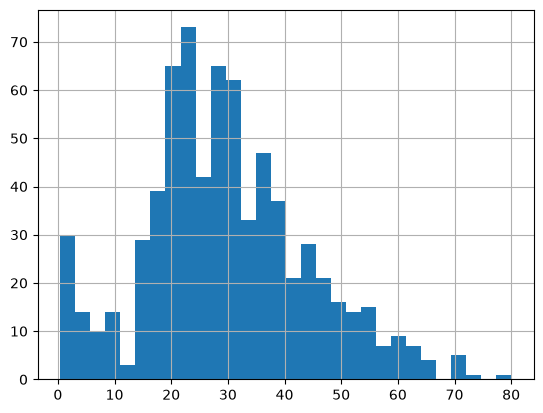

In [81]:
import matplotlib.pyplot as plt

df["Age"].hist(bins=30)
plt.show()

In [25]:
# give me statitical of numberic columns
df.describe()

,Age,Fare
count,712.000000,889.000000
mean,29.642093,32.096681
std,14.492933,49.697504
min,0.420000,0.000000
25%,20.000000,7.895800
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


In [26]:
median=df['Age'].median()
df['Age']=df['Age'].fillna(median)

In [27]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [28]:
# 1- sort data  2- get median  3- then get Q1 , Q3  4- then get IQR = Q3-Q1  5- lower fence -> Q1-1.5*IQR  , upper fence -> Q3+1.5*IQR